# Imports

In [1]:
# Library imports
import ast
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

import matplotlib.pyplot as plt
plt.style.use('my_style.mplstyle')
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import pickle

from regions import Regions

from photutils.aperture import ApertureMask
from photutils.aperture import aperture_photometry
from photutils.aperture import EllipticalAperture
# Local imports
import run_constants as rc
import plot_constants as pc
from general_functions import mask_stacked_cube
high_res_sample = rc.high_res_sample
high_res_sample_ang = rc.high_res_sample_ang


In [2]:
df = pd.read_csv('df_final.csv')
df_ang = pd.read_csv('df_ang.csv')
df_phy = pd.read_csv('df_phy.csv')

with open("PI_flux_jy_dict_regrid_ang.pkl", "rb") as f:
    PI_flux_jy_dict_regrid_ang = pickle.load(f)
    
with open("PI_flux_jy_dict_regrid_ang_sky_sub.pkl", "rb") as f:
    PI_flux_jy_dict_regrid_ang_sky_sub = pickle.load(f)
    
with open("PI_flux_jy_dict_regrid_phy_sky_sub.pkl", "rb") as f:
    PI_flux_jy_dict_regrid_phy_sky_sub = pickle.load(f)    
    
with open("noise_dict_PI_stacks.pkl", "rb") as f:
    noise_dict_PI_stacks = pickle.load(f)
    
#high_rm_galaxies = ["NGC2683", "NGC3003", "NGC3628"]
high_rm_galaxies = ["NGC2683", "NGC3003", "NGC3628", "NGC4666"]


high_rm_gal = ['NGC3003','NGC2683','NGC3628',
               'NGC4666','NGC3432','NGC4096',
               'NGC3877','NGC4302','NGC4013',
               'NGC891']
low_rm_gal = ['NGC4157','NGC5775','NGC4217',
              'NGC4631','NGC2613','NGC3556',
              'NGC3044','NGC4565','NGC4192',
              'NGC5907','NGC3079']

# Stacking

## Angular


### standard (no extra alignment)

In [4]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap_ang = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits")
    u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
    heatmap_ang += heatmap_gal
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid[i,:,:]       
        # U 
        u_slice = u_regrid[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")
    
q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_standard_noNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_standard_noNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_standard_noNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_standard_noNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 10 to stack slice 11
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 11 to

/tmp/ipykernel_2034906/3700954753.py:53: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/3700954753.py:54: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/3700954753.py:55: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/3700954753.py:56: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


/tmp/ipykernel_2034906/2070021139.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  h = ax.imshow(heatmap_ang, cmap=plt.cm.get_cmap("tab20b",n_unique_values-6), origin="lower", vmin=5)


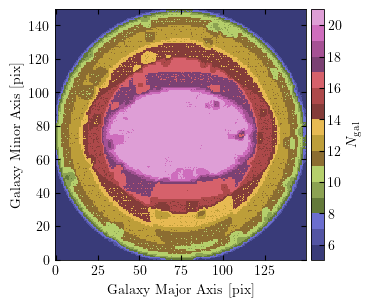

In [5]:
n_unique_values = len(np.unique(heatmap_ang))
fig, ax = plt.subplots(figsize=(pc.one_c))
h = ax.imshow(heatmap_ang, cmap=plt.cm.get_cmap("tab20b",n_unique_values-6), origin="lower", vmin=5)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
colorbar = plt.colorbar(h, cax=cax)
colorbar.set_label(r'$N_{\mathrm{gal}}$')
colorbar.ax.set_yticks([6,8,10,12,14,16,18,20])

ax.set_xlabel("Galaxy Major Axis [pix]")
ax.set_ylabel("Galaxy Minor Axis [pix]")
fig.savefig("plots/heatmap_stack_ang_standard.png", bbox_inches="tight", dpi=300)


### standard - flux normalised

In [6]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits")
    u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits")
    gal_id = f"n{gal[3:]}"
    # pi_flux = PI_flux_jy_dict_regrid_ang[gal_id]
    pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    q_regrid_norm = q_regrid / pi_flux
    u_regrid_norm = u_regrid / pi_flux
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid_norm[i,:,:]       
        # U 
        u_slice = u_regrid_norm[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")
    
q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_standard_piNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_standard_piNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_standard_piNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_standard_piNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 10 to stack slice 11
Sli

/tmp/ipykernel_2034906/1615273593.py:54: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/1615273593.py:55: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/1615273593.py:56: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/1615273593.py:57: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### standard - flux_normalised - exclude high RMs

In [7]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if gal in high_rm_galaxies:
        print(f"Skip {gal}, due to high RM")
        continue
    else:
        print(f"Adding {gal} to the stack:")
        freq_map = row['mapping_to_reference_C']
        freq_map = ast.literal_eval(freq_map)
        print(f"Frequency Mapping reference: {freq_map}")
        q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits")
        gal_id = f"n{gal[3:]}"
        #pi_flux = PI_flux_jy_dict_regrid_ang[gal_id]
        pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]

        print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        q_regrid_norm = q_regrid / pi_flux
        u_regrid_norm = u_regrid / pi_flux
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid_norm[i,:,:]       
            # U 
            u_slice = u_regrid_norm[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
        print("Done with this galaxy")
    
q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_standard_piNorm_mean_exclhighrm.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_standard_piNorm_mean_exclhighrm.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_standard_piNorm_median_exclhighrm.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_standard_piNorm_median_exclhighrm.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 10 to stack slice 11
Sli

/tmp/ipykernel_2034906/2817947431.py:59: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/2817947431.py:60: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/2817947431.py:61: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/2817947431.py:62: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### align (Approaching side on the left side)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 10 to stack slice 11
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 11 to

/tmp/ipykernel_2034906/4181973120.py:58: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/4181973120.py:59: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/4181973120.py:60: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/4181973120.py:61: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])
/tmp/ipykernel_2034906/4181973120.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  h = ax.imshow(heatmap, cmap=plt.cm.get_cmap("tab20b",n_unique_values-6), origin="lower", vmin=5)


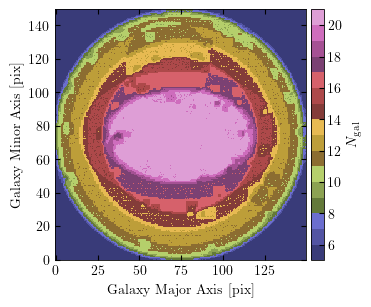

In [8]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    if row['extra_rot']=="yes":
        print("Use Q- & U-Cubes with extra rotation.")
        q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits")
    else:
        q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
    heatmap += heatmap_gal
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid[i,:,:]       
        # U 
        u_slice = u_regrid[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_align_noNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_noNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_align_noNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_noNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

n_unique_values = len(np.unique(heatmap))
fig, ax = plt.subplots(figsize=(pc.one_c))
h = ax.imshow(heatmap, cmap=plt.cm.get_cmap("tab20b",n_unique_values-6), origin="lower", vmin=5)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
colorbar = plt.colorbar(h, cax=cax)
colorbar.set_label(r'$N_{\mathrm{gal}}$')
ax.set_xlabel("Galaxy Major Axis [pix]")
ax.set_ylabel("Galaxy Minor Axis [pix]")
fig.savefig("plots/heatmap_stack_ang_align.png", bbox_inches="tight", dpi=300)

### align - flux normalised

In [9]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    if row['extra_rot']=="yes":
        print("Use Q- & U-Cubes with extra rotation.")
        q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits")
    else:
        q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits")
    gal_id = f"n{gal[3:]}"
    #pi_flux = PI_flux_jy_dict_regrid_ang[gal_id]
    pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    q_regrid_norm = q_regrid / pi_flux
    u_regrid_norm = u_regrid / pi_flux
    heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
    heatmap += heatmap_gal
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid_norm[i,:,:]       
        # U 
        u_slice = u_regrid_norm[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 10 to stack slice 11
Sli

/tmp/ipykernel_2034906/1416516224.py:64: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/1416516224.py:65: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/1416516224.py:66: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/1416516224.py:67: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### align - flux normalised -exlcude high RMs

### align - flux normalised high RM

In [10]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if gal in high_rm_gal:
        print(f"Adding {gal} to the stack:")
        freq_map = row['mapping_to_reference_C']
        freq_map = ast.literal_eval(freq_map)
        print(f"Frequency Mapping reference: {freq_map}")
        print("Use both realizations of each galaxy")
        q_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits"]
        u_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits"]
        print(q_fits_files, u_fits_files)
        gal_id = f"n{gal[3:]}"
        pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
        print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
        for j in range(len(q_fits_files)):
            q_fits = fits.open(q_fits_files[j])
            u_fits = fits.open(u_fits_files[j])
            q_regrid = q_fits[0].data
            u_regrid = u_fits[0].data
            q_regrid_norm = q_regrid / pi_flux
            u_regrid_norm = u_regrid / pi_flux
            heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
            heatmap += heatmap_gal
            q_head, u_head = q_fits[0].header, u_fits[0].header
            for i in range(len(freq_map)):
                print(f"Adding Slice {i} to stack slice {freq_map[i]}")
                # Q
                q_slice = q_regrid_norm[i,:,:]       
                # U 
                u_slice = u_regrid_norm[i,:,:]
                print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
                for j in range(npix):
                    for k in range(npix):
                        q_val = q_slice[j, k]
                        u_val = u_slice[j, k]
                        q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                        u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
        print("Done with this galaxy")
    else:
        continue

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_mean_highrm.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_mean_highrm.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_median_highrm.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_median_highrm.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang/NGC891_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang/NGC891_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_u_extra180_regrid_ang.fits']
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: 

/tmp/ipykernel_2034906/3797633278.py:66: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/3797633278.py:67: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/3797633278.py:68: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/3797633278.py:69: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### align - flux normalised low RM

In [11]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if gal in low_rm_gal:
        print(f"Adding {gal} to the stack:")
        freq_map = row['mapping_to_reference_C']
        freq_map = ast.literal_eval(freq_map)
        print(f"Frequency Mapping reference: {freq_map}")
        print("Use both realizations of each galaxy")
        q_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits"]
        u_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits"]
        print(q_fits_files, u_fits_files)
        gal_id = f"n{gal[3:]}"
        pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
        print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
        for j in range(len(q_fits_files)):
            q_fits = fits.open(q_fits_files[j])
            u_fits = fits.open(u_fits_files[j])
            q_regrid = q_fits[0].data
            u_regrid = u_fits[0].data
            q_regrid_norm = q_regrid / pi_flux
            u_regrid_norm = u_regrid / pi_flux
            heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
            heatmap += heatmap_gal
            q_head, u_head = q_fits[0].header, u_fits[0].header
            for i in range(len(freq_map)):
                print(f"Adding Slice {i} to stack slice {freq_map[i]}")
                # Q
                q_slice = q_regrid_norm[i,:,:]       
                # U 
                u_slice = u_regrid_norm[i,:,:]
                print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
                for j in range(npix):
                    for k in range(npix):
                        q_val = q_slice[j, k]
                        u_val = u_slice[j, k]
                        q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                        u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
        print("Done with this galaxy")
    else:
        continue

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_mean_lowrm.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_mean_lowrm.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_median_lowrm.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_median_lowrm.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
-----
Adding NGC2613 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang/NGC2613_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC2613_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang/NGC2613_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC2613_u_extra180_regrid_ang.fits']
PI Flux is 0.000904278 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Sl

/tmp/ipykernel_2034906/1025442175.py:66: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/1025442175.py:67: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/1025442175.py:68: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/1025442175.py:69: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


In [12]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if gal in high_rm_galaxies:
        print(f"Skip {gal}, due to high RM")
        continue
    else:
        print(f"Adding {gal} to the stack:")
        freq_map = row['mapping_to_reference_C']
        freq_map = ast.literal_eval(freq_map)
        print(f"Frequency Mapping reference: {freq_map}")
        if row['extra_rot']=="yes":
            print("Use Q- & U-Cubes with extra rotation.")
            q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits")
            u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits")
        else:
            q_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits")
            u_fits = fits.open(f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits")
        gal_id = f"n{gal[3:]}"
        #pi_flux = PI_flux_jy_dict_regrid_ang[gal_id]
        pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
        print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        q_regrid_norm = q_regrid / pi_flux
        u_regrid_norm = u_regrid / pi_flux
        heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
        heatmap += heatmap_gal
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid_norm[i,:,:]       
            # U 
            u_slice = u_regrid_norm[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
        print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_mean_exclhighrm.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_mean_exclhighrm.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_align_piNorm_median_exclhighrm.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_align_piNorm_median_exclhighrm.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 10 to stack slice 11
Sli

/tmp/ipykernel_2034906/1196162932.py:68: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/1196162932.py:69: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/1196162932.py:70: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/1196162932.py:71: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both (2 realizations, rotated by 180 deg, of each galaxy)

In [13]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    print("Use both realizations of each galaxy")
    q_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits"]
    u_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits"]
    print(q_fits_files, u_fits_files)
    for j in range(len(q_fits_files)):
        q_fits = fits.open(q_fits_files[j])
        u_fits = fits.open(u_fits_files[j])
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
        heatmap += heatmap_gal
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid[i,:,:]       
            # U 
            u_slice = u_regrid[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_both_noNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_noNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_both_noNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_noNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang/NGC891_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang/NGC891_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_u_extra180_regrid_ang.fits']
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 7 to stack slice 7


/tmp/ipykernel_2034906/2090018098.py:58: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/2090018098.py:59: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/2090018098.py:60: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/2090018098.py:61: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


/tmp/ipykernel_2034906/2061585757.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  h = ax.imshow(heatmap, cmap=plt.cm.get_cmap("tab20b",16), origin="lower", vmin=10)


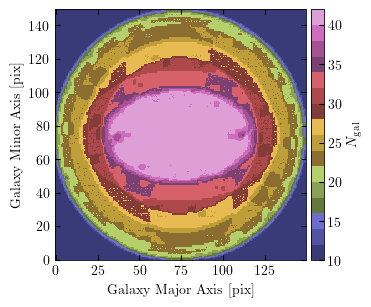

In [14]:
n_unique_values = len(np.unique(heatmap))
fig, ax = plt.subplots(figsize=(pc.one_c))
h = ax.imshow(heatmap, cmap=plt.cm.get_cmap("tab20b",16), origin="lower", vmin=10)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
colorbar = plt.colorbar(h, cax=cax)
colorbar.set_label(r'$N_{\mathrm{gal}}$')
ax.set_xlabel("Galaxy Major Axis [pix]")
ax.set_ylabel("Galaxy Minor Axis [pix]")
fig.savefig("plots/heatmap_stack_ang_both.png", bbox_inches="tight", dpi=300)

### both - flux normalised

In [15]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    print("Use both realizations of each galaxy")
    q_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits"]
    u_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits"]
    print(q_fits_files, u_fits_files)
    gal_id = f"n{gal[3:]}"
    pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    for j in range(len(q_fits_files)):
        q_fits = fits.open(q_fits_files[j])
        u_fits = fits.open(u_fits_files[j])
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        q_regrid_norm = q_regrid / pi_flux
        u_regrid_norm = u_regrid / pi_flux
        heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
        heatmap += heatmap_gal
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid_norm[i,:,:]       
            # U 
            u_slice = u_regrid_norm[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang/NGC891_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang/NGC891_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_u_extra180_regrid_ang.fits']
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: 

/tmp/ipykernel_2034906/241274938.py:63: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/241274938.py:64: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/241274938.py:65: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/241274938.py:66: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both - flux normalised - highres

In [16]:
npix = rc.regrid_npix_ang_hr

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if not gal in high_res_sample_ang:
        print(f"Skipping galaxy {gal} as it is not in the high-res sample.")
        continue
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    print("Use both realizations of each galaxy")
    q_fits_files = [f"cube_processing/qu_regrid_ang_highres/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang_highres/{gal}_q_extra180_regrid_ang.fits"]
    u_fits_files = [f"cube_processing/qu_regrid_ang_highres/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang_highres/{gal}_u_extra180_regrid_ang.fits"]
    print(q_fits_files, u_fits_files)
    gal_id = f"n{gal[3:]}"
    pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    for j in range(len(q_fits_files)):
        q_fits = fits.open(q_fits_files[j])
        u_fits = fits.open(u_fits_files[j])
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        q_regrid_norm = q_regrid / pi_flux
        u_regrid_norm = u_regrid / pi_flux
        heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
        heatmap += heatmap_gal
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid_norm[i,:,:]       
            # U 
            u_slice = u_regrid_norm[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang_highres/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_mean_highres.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_mean_highres.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_median_highres.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_median_highres.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang_highres/NGC891_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang_highres/NGC891_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang_highres/NGC891_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang_highres/NGC891_u_extra180_regrid_ang.fits']
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 6 to

/tmp/ipykernel_2034906/1176928314.py:66: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/1176928314.py:67: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/1176928314.py:68: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/1176928314.py:69: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both- flux normalised - exclude high RMs

In [17]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if gal in high_rm_galaxies:
        print(f"Skip {gal}, due to high RM")
        continue
    else:
        print(f"Adding {gal} to the stack:")
        freq_map = row['mapping_to_reference_C']
        freq_map = ast.literal_eval(freq_map)
        print(f"Frequency Mapping reference: {freq_map}")
        print("Use both realizations of each galaxy")
        q_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits"]
        u_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits"]
        print(q_fits_files, u_fits_files)
        gal_id = f"n{gal[3:]}"
        pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
        print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
        for j in range(len(q_fits_files)):
            q_fits = fits.open(q_fits_files[j])
            u_fits = fits.open(u_fits_files[j])
            q_regrid = q_fits[0].data
            u_regrid = u_fits[0].data
            q_regrid_norm = q_regrid / pi_flux
            u_regrid_norm = u_regrid / pi_flux
            heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
            heatmap += heatmap_gal
            q_head, u_head = q_fits[0].header, u_fits[0].header
            for i in range(len(freq_map)):
                print(f"Adding Slice {i} to stack slice {freq_map[i]}")
                # Q
                q_slice = q_regrid_norm[i,:,:]       
                # U 
                u_slice = u_regrid_norm[i,:,:]
                print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
                for j in range(npix):
                    for k in range(npix):
                        q_val = q_slice[j, k]
                        u_val = u_slice[j, k]
                        q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                        u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
        print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_mean_exclhighrm.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_mean_exclhighrm.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_median_exclhighrm.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_median_exclhighrm.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang/NGC891_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang/NGC891_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_u_extra180_regrid_ang.fits']
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: 

/tmp/ipykernel_2034906/3239036417.py:67: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/3239036417.py:68: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/3239036417.py:69: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/3239036417.py:70: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both - flux normalised high RM

In [18]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if gal in high_rm_gal:
        print(f"Adding {gal} to the stack:")
        freq_map = row['mapping_to_reference_C']
        freq_map = ast.literal_eval(freq_map)
        print(f"Frequency Mapping reference: {freq_map}")
        print("Use both realizations of each galaxy")
        q_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits"]
        u_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits"]
        print(q_fits_files, u_fits_files)
        gal_id = f"n{gal[3:]}"
        pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
        print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
        for j in range(len(q_fits_files)):
            q_fits = fits.open(q_fits_files[j])
            u_fits = fits.open(u_fits_files[j])
            q_regrid = q_fits[0].data
            u_regrid = u_fits[0].data
            q_regrid_norm = q_regrid / pi_flux
            u_regrid_norm = u_regrid / pi_flux
            heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
            heatmap += heatmap_gal
            q_head, u_head = q_fits[0].header, u_fits[0].header
            for i in range(len(freq_map)):
                print(f"Adding Slice {i} to stack slice {freq_map[i]}")
                # Q
                q_slice = q_regrid_norm[i,:,:]       
                # U 
                u_slice = u_regrid_norm[i,:,:]
                print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
                for j in range(npix):
                    for k in range(npix):
                        q_val = q_slice[j, k]
                        u_val = u_slice[j, k]
                        q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                        u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
        print("Done with this galaxy")
    else:
        continue

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_mean_highrm.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_mean_highrm.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_median_highrm.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_median_highrm.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang/NGC891_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang/NGC891_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC891_u_extra180_regrid_ang.fits']
PI Flux is 0.00601777 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Slice shapes: Q: 

/tmp/ipykernel_2034906/2508463821.py:66: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/2508463821.py:67: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/2508463821.py:68: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/2508463821.py:69: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both - flux normalised low RM

In [19]:
npix = rc.regrid_npix_ang

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Angular Scaling) -----")
for index, row in df_ang.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if gal in low_rm_gal:
        print(f"Adding {gal} to the stack:")
        freq_map = row['mapping_to_reference_C']
        freq_map = ast.literal_eval(freq_map)
        print(f"Frequency Mapping reference: {freq_map}")
        print("Use both realizations of each galaxy")
        q_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_q_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_q_extra180_regrid_ang.fits"]
        u_fits_files = [f"cube_processing/qu_regrid_ang/{gal}_u_regrid_ang.fits",f"cube_processing/qu_regrid_ang/{gal}_u_extra180_regrid_ang.fits"]
        print(q_fits_files, u_fits_files)
        gal_id = f"n{gal[3:]}"
        pi_flux = PI_flux_jy_dict_regrid_ang_sky_sub[gal_id][0]
        print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
        for j in range(len(q_fits_files)):
            q_fits = fits.open(q_fits_files[j])
            u_fits = fits.open(u_fits_files[j])
            q_regrid = q_fits[0].data
            u_regrid = u_fits[0].data
            q_regrid_norm = q_regrid / pi_flux
            u_regrid_norm = u_regrid / pi_flux
            heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
            heatmap += heatmap_gal
            q_head, u_head = q_fits[0].header, u_fits[0].header
            for i in range(len(freq_map)):
                print(f"Adding Slice {i} to stack slice {freq_map[i]}")
                # Q
                q_slice = q_regrid_norm[i,:,:]       
                # U 
                u_slice = u_regrid_norm[i,:,:]
                print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
                for j in range(npix):
                    for k in range(npix):
                        q_val = q_slice[j, k]
                        u_val = u_slice[j, k]
                        q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                        u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
        print("Done with this galaxy")
    else:
        continue

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_ang/NGC5775_q_regrid_ang.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_mean_lowrm.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_mean_lowrm.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_ang_both_piNorm_median_lowrm.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_ang_both_piNorm_median_lowrm.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Angular Scaling) -----
-----
-----
Adding NGC2613 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_ang/NGC2613_q_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC2613_q_extra180_regrid_ang.fits'] ['cube_processing/qu_regrid_ang/NGC2613_u_regrid_ang.fits', 'cube_processing/qu_regrid_ang/NGC2613_u_extra180_regrid_ang.fits']
PI Flux is 0.000904278 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (150, 150); U: (150, 150)
Adding Slice 6 to stack slice 6
Sl

/tmp/ipykernel_2034906/3423470060.py:66: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/3423470060.py:67: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/3423470060.py:68: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/3423470060.py:69: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


## Physical

### standard - flux normalised

In [20]:
npix = rc.n_pix_phy_ref_frame
heatmap_shape = (npix, npix)
heatmap_phy = np.zeros(heatmap_shape)
# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_regrid_phy.fits")
    u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_regrid_phy.fits")
    gal_id = f"n{gal[3:]}"
    # pi_flux = PI_flux_jy_dict_regrid_ang[gal_id]
    pi_flux = PI_flux_jy_dict_regrid_phy_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    q_regrid_norm = q_regrid / pi_flux
    u_regrid_norm = u_regrid / pi_flux
    heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
    heatmap_phy += heatmap_gal
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid_norm[i,:,:]       
        # U 
        u_slice = u_regrid_norm[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")
    
q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy/NGC5775_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_standard_piNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_standard_piNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_standard_piNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_standard_piNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
PI Flux is 0.00796799 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 10 to stack slice 11
Sl

/tmp/ipykernel_2034906/4018520805.py:57: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/4018520805.py:58: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/4018520805.py:59: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/4018520805.py:60: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


/tmp/ipykernel_2034906/2207997754.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  h = ax.imshow(heatmap_phy, cmap=plt.cm.get_cmap("tab20b",n_unique_values-8), origin="lower", vmin=7)


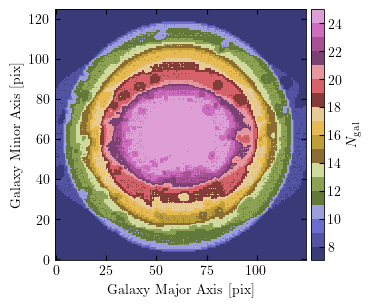

In [21]:
n_unique_values = len(np.unique(heatmap_phy))
fig, ax = plt.subplots(figsize=(pc.one_c))
h = ax.imshow(heatmap_phy, cmap=plt.cm.get_cmap("tab20b",n_unique_values-8), origin="lower", vmin=7)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
colorbar = plt.colorbar(h, cax=cax)
colorbar.set_label(r'$N_{\mathrm{gal}}$')
colorbar.ax.set_yticks([8,10,12,14,16,18,20,22,24])
ax.set_xlabel("Galaxy Major Axis [pix]")
ax.set_ylabel("Galaxy Minor Axis [pix]")
fig.savefig("plots/heatmap_stack_phy_standard.png", bbox_inches="tight", dpi=300)


### standard - dist normalised

In [22]:
npix = rc.n_pix_phy_ref_frame

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_regrid_phy.fits")
    u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_regrid_phy.fits")
    gal_id = f"n{gal[3:]}"
    # pi_flux = PI_flux_jy_dict_regrid_ang[gal_id]
    dist = row['d[Mpc]']
    dist_norm_fac = (dist/rc.ref_distance_Mpc)**2
    print(f"Galaxy Distance: {dist} Mpc, normalisation factor: {dist_norm_fac} ")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    q_regrid_norm = q_regrid * dist_norm_fac
    u_regrid_norm = u_regrid * dist_norm_fac
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid_norm[i,:,:]       
        # U 
        u_slice = u_regrid_norm[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")
    
q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy/NGC5775_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_standard_distNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_standard_distNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_standard_distNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_standard_distNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Galaxy Distance: 9.1 Mpc, normalisation factor: 0.20702499999999996 
Adding Slice 0 to stack slice 0
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 10 to stack 

/tmp/ipykernel_2034906/3869582534.py:55: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/3869582534.py:56: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/3869582534.py:57: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/3869582534.py:58: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### align - flux normalised

In [23]:
npix = rc.n_pix_phy_ref_frame

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    if row['extra_rot']=="yes":
        print("Use Q- & U-Cubes with extra rotation.")
        q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_extra180_regrid_phy.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_extra180_regrid_phy.fits")
    else:
        q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_regrid_phy.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_regrid_phy.fits")
    gal_id = f"n{gal[3:]}"
    #pi_flux = PI_flux_jy_dict_regrid_phy[gal_id]
    pi_flux = PI_flux_jy_dict_regrid_phy_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    q_regrid_norm = q_regrid / pi_flux
    u_regrid_norm = u_regrid / pi_flux
    heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
    heatmap += heatmap_gal
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid_norm[i,:,:]       
        # U 
        u_slice = u_regrid_norm[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy/NGC5775_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_align_piNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_align_piNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_align_piNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_align_piNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
PI Flux is 0.00796799 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 10 to stack slice 11
Sl

/tmp/ipykernel_2034906/1006686508.py:64: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/1006686508.py:65: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/1006686508.py:66: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/1006686508.py:67: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### align - flux normalised - ang sample

In [24]:
npix = rc.n_pix_phy_ref_frame

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    if not row['include_angular']:
        print(f"Skipping {row['galaxy']} as include_angular is set to False.")
        continue
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    if row['extra_rot']=="yes":
        print("Use Q- & U-Cubes with extra rotation.")
        q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_extra180_regrid_phy.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_extra180_regrid_phy.fits")
    else:
        q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_regrid_phy.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_regrid_phy.fits")
    gal_id = f"n{gal[3:]}"
    #pi_flux = PI_flux_jy_dict_regrid_phy[gal_id]
    pi_flux = PI_flux_jy_dict_regrid_phy_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    q_regrid_norm = q_regrid / pi_flux
    u_regrid_norm = u_regrid / pi_flux
    heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
    heatmap += heatmap_gal
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid_norm[i,:,:]       
        # U 
        u_slice = u_regrid_norm[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy/NGC5775_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_align_piNorm_mean_ang_sample.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_align_piNorm_mean_ang_sample.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_align_piNorm_median_ang_sample.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_align_piNorm_median_ang_sample.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
PI Flux is 0.00796799 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 10 to stack slice 11
Sl

/tmp/ipykernel_2034906/2509982553.py:67: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/2509982553.py:68: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/2509982553.py:69: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/2509982553.py:70: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### align - dist normalised

In [25]:
npix = rc.n_pix_phy_ref_frame

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    if row['extra_rot']=="yes":
        print("Use Q- & U-Cubes with extra rotation.")
        q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_extra180_regrid_phy.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_extra180_regrid_phy.fits")
    else:
        q_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_q_regrid_phy.fits")
        u_fits = fits.open(f"cube_processing/qu_regrid_phy/{gal}_u_regrid_phy.fits")
    gal_id = f"n{gal[3:]}"
    #pi_flux = PI_flux_jy_dict_regrid_phy[gal_id]
    dist = row['d[Mpc]']
    dist_norm_fac = (dist/rc.ref_distance_Mpc)**2
    print(f"Galaxy Distance: {dist} Mpc, normalisation factor: {dist_norm_fac} ")
    q_regrid = q_fits[0].data
    u_regrid = u_fits[0].data
    q_regrid_norm = q_regrid * dist_norm_fac
    u_regrid_norm = u_regrid * dist_norm_fac
    heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
    heatmap += heatmap_gal
    q_head, u_head = q_fits[0].header, u_fits[0].header
    for i in range(len(freq_map)):
        print(f"Adding Slice {i} to stack slice {freq_map[i]}")
        # Q
        q_slice = q_regrid_norm[i,:,:]       
        # U 
        u_slice = u_regrid_norm[i,:,:]
        print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
        for j in range(npix):
            for k in range(npix):
                q_val = q_slice[j, k]
                u_val = u_slice[j, k]
                q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy/NGC5775_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_align_distNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_align_distNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_align_distNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_align_distNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)


----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Galaxy Distance: 9.1 Mpc, normalisation factor: 0.20702499999999996 
Adding Slice 0 to stack slice 0
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 6 to stack slice 6
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 7 to stack slice 7
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 8 to stack slice 8
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 9 to stack slice 10
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 10 to stack 

/tmp/ipykernel_2034906/3667969105.py:65: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/3667969105.py:66: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/3667969105.py:67: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/3667969105.py:68: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both - flux normalised

In [26]:
npix = rc.n_pix_phy_ref_frame

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    print("Use both realizations of each galaxy")
    q_fits_files = [f"cube_processing/qu_regrid_phy/{gal}_q_regrid_phy.fits",f"cube_processing/qu_regrid_phy/{gal}_q_extra180_regrid_phy.fits"]
    u_fits_files = [f"cube_processing/qu_regrid_phy/{gal}_u_regrid_phy.fits",f"cube_processing/qu_regrid_phy/{gal}_u_extra180_regrid_phy.fits"]
    print(q_fits_files, u_fits_files)
    gal_id = f"n{gal[3:]}"
    pi_flux = PI_flux_jy_dict_regrid_phy_sky_sub[gal_id][0]
    print(f"PI Flux is {pi_flux} Jy. Normalise data using this flux.")
    for j in range(len(q_fits_files)):
        q_fits = fits.open(q_fits_files[j])
        u_fits = fits.open(u_fits_files[j])
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        q_regrid_norm = q_regrid / pi_flux
        u_regrid_norm = u_regrid / pi_flux
        heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
        heatmap += heatmap_gal
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid_norm[i,:,:]       
            # U 
            u_slice = u_regrid_norm[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy/NGC5775_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_both_piNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_both_piNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_both_piNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_both_piNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_phy/NGC891_q_regrid_phy.fits', 'cube_processing/qu_regrid_phy/NGC891_q_extra180_regrid_phy.fits'] ['cube_processing/qu_regrid_phy/NGC891_u_regrid_phy.fits', 'cube_processing/qu_regrid_phy/NGC891_u_extra180_regrid_phy.fits']
PI Flux is 0.00796799 Jy. Normalise data using this flux.
Adding Slice 0 to stack slice 0
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 6 to stack slice 6
Slice shapes: Q:

/tmp/ipykernel_2034906/1840918033.py:63: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/1840918033.py:64: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/1840918033.py:65: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/1840918033.py:66: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both - dist normalised

In [27]:
npix = rc.n_pix_phy_ref_frame

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    print("Use both realizations of each galaxy")
    q_fits_files = [f"cube_processing/qu_regrid_phy/{gal}_q_regrid_phy.fits",f"cube_processing/qu_regrid_phy/{gal}_q_extra180_regrid_phy.fits"]
    u_fits_files = [f"cube_processing/qu_regrid_phy/{gal}_u_regrid_phy.fits",f"cube_processing/qu_regrid_phy/{gal}_u_extra180_regrid_phy.fits"]
    print(q_fits_files, u_fits_files)
    gal_id = f"n{gal[3:]}"
    dist = row['d[Mpc]']
    dist_norm_fac = (dist/rc.ref_distance_Mpc)**2
    print(f"Galaxy Distance: {dist} Mpc, normalisation factor: {dist_norm_fac} ")
    for j in range(len(q_fits_files)):    
        q_fits = fits.open(q_fits_files[j])
        u_fits = fits.open(u_fits_files[j])
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        q_regrid_norm = q_regrid * dist_norm_fac
        u_regrid_norm = u_regrid * dist_norm_fac
        heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
        heatmap += heatmap_gal
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid_norm[i,:,:]       
            # U 
            u_slice = u_regrid_norm[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy/NGC5775_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_both_distNorm_mean.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_both_distNorm_mean.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_both_distNorm_median.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_both_distNorm_median.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_phy/NGC891_q_regrid_phy.fits', 'cube_processing/qu_regrid_phy/NGC891_q_extra180_regrid_phy.fits'] ['cube_processing/qu_regrid_phy/NGC891_u_regrid_phy.fits', 'cube_processing/qu_regrid_phy/NGC891_u_extra180_regrid_phy.fits']
Galaxy Distance: 9.1 Mpc, normalisation factor: 0.20702499999999996 
Adding Slice 0 to stack slice 0
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (125, 125); U: (125, 125)
Adding Slice 6 to stack slice 6
Slice

/tmp/ipykernel_2034906/933986135.py:64: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/933986135.py:65: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/933986135.py:66: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/933986135.py:67: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


### both - dist normalised - highres

In [28]:
npix = rc.n_pix_phy_ref_frame_hr

# Create an empty 3D array with dtype=object
q_stack = np.empty((npix, npix, 16), dtype=object)
u_stack = np.empty((npix, npix, 16), dtype=object)

# Fill the array with empty 1D numpy arrays
for i in range(npix):
    for j in range(npix):
        for k in range(16):
            q_stack[i, j, k] = np.array([])
            u_stack[i, j, k] = np.array([])

heatmap_shape = (npix, npix)
heatmap = np.zeros(heatmap_shape)

print("----- Stacking (Physical Scaling) -----")
for index, row in df_phy.iterrows():
    print("-----")
    gal = row['galaxy'].replace(' ', '')
    if not gal in high_res_sample:
        print(f"Skipping galaxy {gal} as it is not in the high-res sample.")
        continue
    print(f"Adding {gal} to the stack:")
    freq_map = row['mapping_to_reference_C']
    freq_map = ast.literal_eval(freq_map)
    print(f"Frequency Mapping reference: {freq_map}")
    print("Use both realizations of each galaxy")
    q_fits_files = [f"cube_processing/qu_regrid_phy_highres/{gal}_q_regrid_phy.fits",f"cube_processing/qu_regrid_phy_highres/{gal}_q_extra180_regrid_phy.fits"]
    u_fits_files = [f"cube_processing/qu_regrid_phy_highres/{gal}_u_regrid_phy.fits",f"cube_processing/qu_regrid_phy_highres/{gal}_u_extra180_regrid_phy.fits"]
    print(q_fits_files, u_fits_files)
    gal_id = f"n{gal[3:]}"
    dist = row['d[Mpc]']
    dist_norm_fac = (dist/rc.ref_distance_Mpc)**2
    print(f"Galaxy Distance: {dist} Mpc, normalisation factor: {dist_norm_fac} ")
    for j in range(len(q_fits_files)):    
        q_fits = fits.open(q_fits_files[j])
        u_fits = fits.open(u_fits_files[j])
        q_regrid = q_fits[0].data
        u_regrid = u_fits[0].data
        q_regrid_norm = q_regrid * dist_norm_fac
        u_regrid_norm = u_regrid * dist_norm_fac
        heatmap_gal = np.where(np.isnan(q_regrid[0,:,:]), 0, 1)
        heatmap += heatmap_gal
        q_head, u_head = q_fits[0].header, u_fits[0].header
        for i in range(len(freq_map)):
            print(f"Adding Slice {i} to stack slice {freq_map[i]}")
            # Q
            q_slice = q_regrid_norm[i,:,:]       
            # U 
            u_slice = u_regrid_norm[i,:,:]
            print(f"Slice shapes: Q: {q_slice.shape}; U: {u_slice.shape}")
            for j in range(npix):
                for k in range(npix):
                    q_val = q_slice[j, k]
                    u_val = u_slice[j, k]
                    q_stack[j, k, freq_map[i]] = np.append(q_stack[j, k, freq_map[i]], q_val)
                    u_stack[j, k, freq_map[i]] = np.append(u_stack[j, k, freq_map[i]], u_val)
    print("Done with this galaxy")

q_stack_mean = np.zeros((npix, npix, 16), dtype=float)
u_stack_mean = np.zeros((npix, npix, 16), dtype=float)
q_stack_median = np.zeros((npix, npix, 16), dtype=float)
u_stack_median = np.zeros((npix, npix, 16), dtype=float)
ref_head = fits.getheader("cube_processing/qu_regrid_phy_highres/NGC891_q_regrid_phy.fits")
for idx in np.ndindex(u_stack.shape):
    q_stack_mean[idx] = np.nanmean(q_stack[idx])
    u_stack_mean[idx] = np.nanmean(u_stack[idx])
    q_stack_median[idx] = np.nanmedian(q_stack[idx])
    u_stack_median[idx] = np.nanmedian(u_stack[idx])
    
# Transpose the arrays to ensure the correct shape in the FITS file
q_stack_mean_transposed = np.transpose(q_stack_mean, (2, 0, 1))
u_stack_mean_transposed = np.transpose(u_stack_mean, (2, 0, 1))
q_stack_median_transposed = np.transpose(q_stack_median, (2, 0, 1))
u_stack_median_transposed = np.transpose(u_stack_median, (2, 0, 1))
fits.writeto(filename="cube_processing/q_stack_phy_both_distNorm_mean_highres.fits",data=q_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_both_distNorm_mean_highres.fits",data=u_stack_mean_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/q_stack_phy_both_distNorm_median_highres.fits",data=q_stack_median_transposed, header=ref_head, overwrite=True)
fits.writeto(filename="cube_processing/u_stack_phy_both_distNorm_median_highres.fits",data=u_stack_median_transposed, header=ref_head, overwrite=True)

----- Stacking (Physical Scaling) -----
-----
Adding NGC891 to the stack:
Frequency Mapping reference: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15]
Use both realizations of each galaxy
['cube_processing/qu_regrid_phy_highres/NGC891_q_regrid_phy.fits', 'cube_processing/qu_regrid_phy_highres/NGC891_q_extra180_regrid_phy.fits'] ['cube_processing/qu_regrid_phy_highres/NGC891_u_regrid_phy.fits', 'cube_processing/qu_regrid_phy_highres/NGC891_u_extra180_regrid_phy.fits']
Galaxy Distance: 9.1 Mpc, normalisation factor: 0.20702499999999996 
Adding Slice 0 to stack slice 0
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 1 to stack slice 1
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 2 to stack slice 2
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 3 to stack slice 3
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 4 to stack slice 4
Slice shapes: Q: (250, 250); U: (250, 250)
Adding Slice 5 to stack slice 5
Slice shapes: Q: (250, 250); U: (250, 250)
Addin

/tmp/ipykernel_2034906/3289312120.py:67: RuntimeWarning: Mean of empty slice
  q_stack_mean[idx] = np.nanmean(q_stack[idx])
/tmp/ipykernel_2034906/3289312120.py:68: RuntimeWarning: Mean of empty slice
  u_stack_mean[idx] = np.nanmean(u_stack[idx])
/tmp/ipykernel_2034906/3289312120.py:69: RuntimeWarning: All-NaN slice encountered
  q_stack_median[idx] = np.nanmedian(q_stack[idx])
/tmp/ipykernel_2034906/3289312120.py:70: RuntimeWarning: All-NaN slice encountered
  u_stack_median[idx] = np.nanmedian(u_stack[idx])


# Masking of stacked cubes

## Angular

### standard

In [29]:
# Mean Angular Scaling
stack_name = "stack_ang_standard_noNorm_mean"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<2.79708985981e-05 [Jy/Beam] (5.0sigma above mean).


Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


0

In [30]:
# Median Angular Scaling
stack_name = "stack_ang_standard_noNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<1.5032473485491999e-05 [Jy/Beam] (5.0sigma above mean).


0

### standard - flux norm

In [31]:
# Mean 
stack_name = "stack_ang_standard_piNorm_mean"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.026595663148325 [Jy/Beam] (5.0sigma above mean).


0

In [32]:
# Median
stack_name = "stack_ang_standard_piNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.009223391123278999 [Jy/Beam] (5.0sigma above mean).


0

### standard - flux norm - exlude high RMs

In [33]:
# Mean 
stack_name = "stack_ang_standard_piNorm_mean_exclhighrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.017501473530499 [Jy/Beam] (5.0sigma above mean).


0

In [34]:
# Median
stack_name = "stack_ang_standard_piNorm_median_exclhighrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.0083298267447865 [Jy/Beam] (5.0sigma above mean).


0

### align

In [35]:
# Mean Angular Scaling (Rotation Alignment)
stack_name = "stack_ang_align_noNorm_mean"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<2.1438946896923e-05 [Jy/Beam] (5.0sigma above mean).


0

In [36]:
# Median Angular Scaling (Rotation Alignment)
stack_name = "stack_ang_align_noNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<1.4225749498728001e-05 [Jy/Beam] (5.0sigma above mean).


0

### align - flux norm

In [37]:
# Mean Angular Scaling (Rotation Alignment)
stack_name = "stack_ang_align_piNorm_mean"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.024008016712631003 [Jy/Beam] (5.0sigma above mean).


0

In [38]:
# Median Angular Scaling (Rotation Alignment)
stack_name = "stack_ang_align_piNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.007835124517347001 [Jy/Beam] (5.0sigma above mean).


0

### align - flux norm - exclude high RMs

In [39]:
# Mean Angular Scaling (Rotation Alignment)
stack_name = "stack_ang_align_piNorm_mean_exclhighrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.01618608516614 [Jy/Beam] (5.0sigma above mean).


0

### align - flux norm - highrm

In [40]:
stack_name = "stack_ang_align_piNorm_median_highrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.016674533095976 [Jy/Beam] (5.0sigma above mean).


0

### align - flux norm - highrm

In [41]:
stack_name = "stack_ang_align_piNorm_median_lowrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")

Clip all pixels in the RM map where PI<0.0075367514152915 [Jy/Beam] (5.0sigma above mean).


0

In [42]:
# Median Angular Scaling (Rotation Alignment)
stack_name = "stack_ang_align_piNorm_median_exclhighrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.008067056362585 [Jy/Beam] (5.0sigma above mean).


0

### both

In [43]:
# Mean Angular Scaling (Both)
stack_name = "stack_ang_both_noNorm_mean"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<1.7416873817994e-05 [Jy/Beam] (5.0sigma above mean).


0

In [44]:
# Median Angular Scaling (Both)
stack_name = "stack_ang_both_noNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<1.3906993479735e-05 [Jy/Beam] (5.0sigma above mean).


0

### both - flux norm

In [45]:
# Mean Angular Scaling (Both)
stack_name = "stack_ang_both_piNorm_mean"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.017836289167878 [Jy/Beam] (5.0sigma above mean).


0

In [46]:
# Median Angular Scaling (Both)
stack_name = "stack_ang_both_piNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.0075275419837945 [Jy/Beam] (5.0sigma above mean).


0

### both - flux norm - exclude high RMs

In [47]:
# Mean Angular Scaling (Both)
stack_name = "stack_ang_both_piNorm_mean_exclhighrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.012403820789042001 [Jy/Beam] (5.0sigma above mean).


0

### both - flux norm - high RM

In [48]:
stack_name = "stack_ang_both_piNorm_median_highrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.016674533095976 [Jy/Beam] (5.0sigma above mean).


0

### both - flux norm - low RM

In [49]:
stack_name = "stack_ang_both_piNorm_median_lowrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.0075367514152915 [Jy/Beam] (5.0sigma above mean).


0

In [50]:
# Median Angular Scaling (Both)
stack_name = "stack_ang_both_piNorm_median_exclhighrm"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.007719545800259 [Jy/Beam] (5.0sigma above mean).


0

## Physical

### standard - flux norm

In [51]:
# Median Physical Scaling
stack_name = "stack_phy_standard_piNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std, phy_stack=True,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.010945562062789 [Jy/Beam] (5.0sigma above mean).


0

### standard - dist norm

In [52]:
# Median Physical Scaling
stack_name = "stack_phy_standard_distNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std, phy_stack=True,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<1.9303739431712e-05 [Jy/Beam] (5.0sigma above mean).


0

### align - flux norm

In [53]:
# Median Physical Scaling
stack_name = "stack_phy_align_piNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std, phy_stack=True,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.009542200420461 [Jy/Beam] (5.0sigma above mean).


0

### align - flux norm - ang sample

In [54]:
# Median Physical Scaling
stack_name = "stack_phy_align_piNorm_median_ang_sample"
mean, std = noise_dict_PI_stacks['stack_phy_align_piNorm_median']
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std, phy_stack=True,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.009542200420461 [Jy/Beam] (5.0sigma above mean).


0

### align - dist norm

In [55]:
# Median Physical Scaling
stack_name = "stack_phy_align_distNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std, phy_stack=True,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<1.4828255260008e-05 [Jy/Beam] (5.0sigma above mean).


0

### both - flux norm

In [56]:
# Median Physical Scaling
stack_name = "stack_phy_both_piNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std, phy_stack=True,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<0.009012961548821 [Jy/Beam] (5.0sigma above mean).


0

### both - dist norm

In [57]:
# Median Physical Scaling
stack_name = "stack_phy_both_distNorm_median"
mean, std = noise_dict_PI_stacks[stack_name]
mask_stacked_cube(rm_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2.fits",
                  pi_map=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_ampPeakPIfitEff.fits",
                  pi_bkg_mean=mean, pi_bkg_std=std, phy_stack=True,
                  outname=f"cube_processing/rm_analysis/3d_cubes/{stack_name}/pf_{stack_name}_phiPeakPIfit_rm2_pi_masked.fits")


Clip all pixels in the RM map where PI<1.4991506217972001e-05 [Jy/Beam] (5.0sigma above mean).


0